In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
customer_features = pd.read_csv(
    "../exports/processed_data/customer_features.csv"
)

In [3]:
customer_features.head()

,customer_id,total_revenue,avg_order_value_x,order_count,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value_y,revenue_per_order,value_score
0,31813,5726.04,2863.020000,2,Indrajit Pau,wakeetasehgal@example.com,911785834174,"66, Vora Chowk\nMaheshtala 376030",Sultan Pur Majra,666762,2024-04-10,Regular,18,1230.75,2863.020000,11452.08
1,61020,7844.90,2614.966667,3,Onkar Suresh,rudradeshpande@example.com,918421031341,"88/40, Bora Zila, Phusro-161515",Kurnool,345635,2024-07-27,New,19,1703.16,2614.966667,23534.70
2,119099,14768.77,3692.192500,4,Zansi Parsa,neha08@example.com,912032907631,"H.No. 40, Gopal Ganj, Bidar 854350",Kavali,692517,2023-08-01,Inactive,20,637.35,3692.192500,59075.08
3,188838,5182.04,2591.020000,2,Idika Basu,deepakhanna@example.com,914955579642,"67, Karan Chowk\nKatihar 496332",Madanapalle,566155,2024-07-16,Inactive,12,799.11,2591.020000,10364.08
4,191616,4089.96,2044.980000,2,Brijesh Tata,yadavipatla@example.org,918144382068,"19/151, Bera Nagar, Surendranagar Dudhrej-068367",Pallavaram,587079,2023-04-27,Regular,4,1053.70,2044.980000,8179.92


In [4]:
customer_features.columns.tolist()

['customer_id',
 'total_revenue',
 'avg_order_value_x',
 'order_count',
 'customer_name',
 'email',
 'phone',
 'address',
 'area',
 'pincode',
 'registration_date',
 'customer_segment',
 'total_orders',
 'avg_order_value_y',
 'revenue_per_order',
 'value_score']

In [6]:
customer_features.rename(
    columns={
        "avg_order_value_x": "calculated_aov",
        "avg_order_value_y": "customer_aov"
    },
    inplace=True
)

In [7]:
customer_features["clv"] = (
    customer_features["calculated_aov"]
    *
    customer_features["order_count"]
    *
    12
)

In [8]:
customer_features["clv_segment"] = pd.qcut(
    customer_features["clv"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Very High Value"
    ]
)

In [9]:
clv_summary = (
    customer_features.groupby(
        "clv_segment"
    )
    .agg({
        "customer_id":"count",
        "clv":"mean",
        "total_revenue":"mean",
        "order_count":"mean"
    })
    .reset_index()
)

clv_summary

,clv_segment,customer_id,clv,total_revenue,order_count
0,Low Value,543,16574.617680,1381.218140,1.246777
1,Medium Value,543,42170.800884,3514.233407,1.747698
2,High Value,543,67633.360663,5636.113389,2.480663
3,Very High Value,543,116920.856133,9743.404678,3.732965


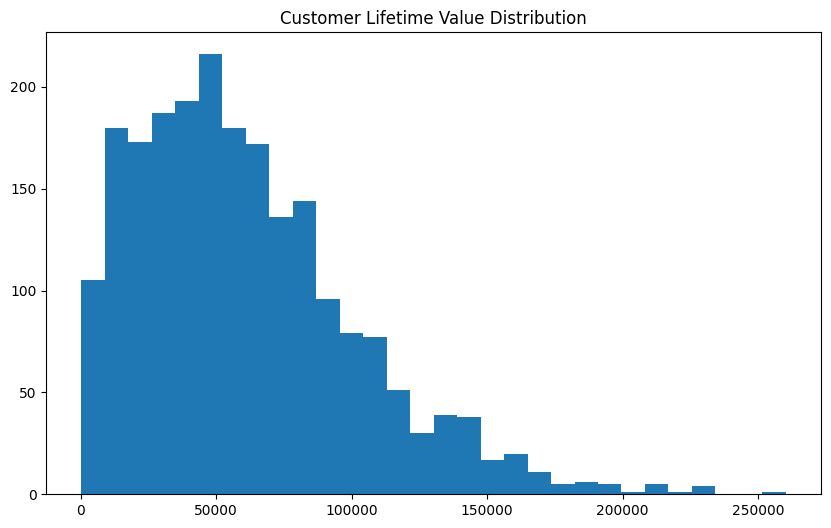

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    customer_features["clv"],
    bins=30
)

plt.title(
    "Customer Lifetime Value Distribution"
)

plt.show()

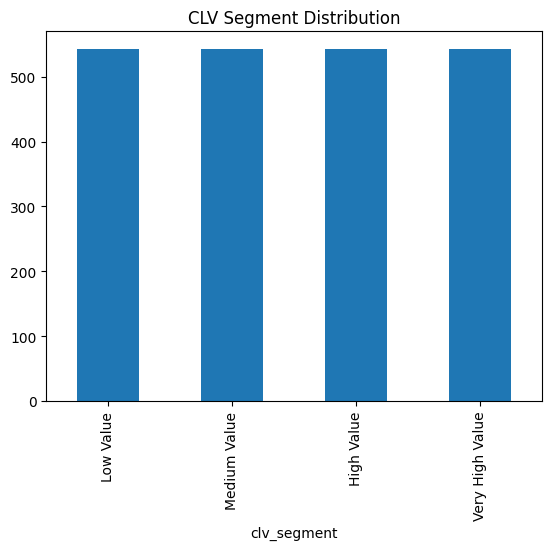

In [11]:
customer_features[
    "clv_segment"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "CLV Segment Distribution"
)

plt.show()

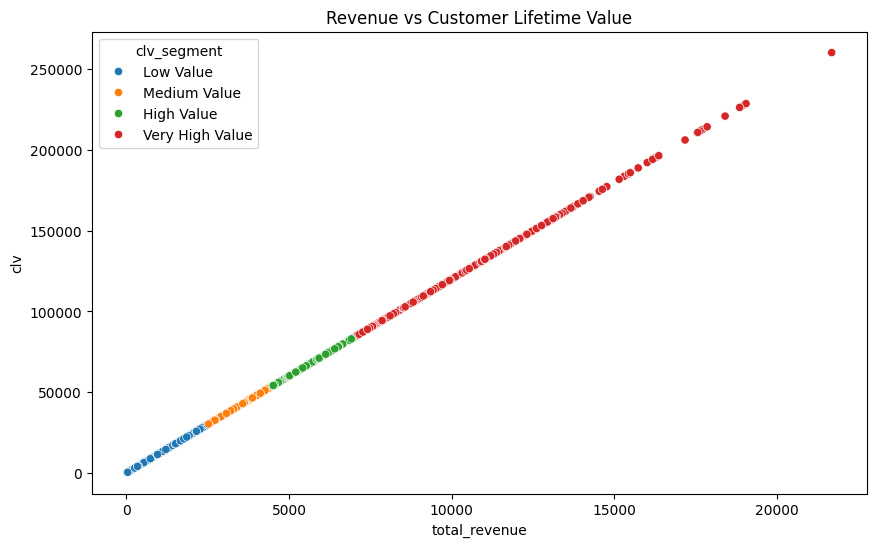

In [12]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_features,
    x="total_revenue",
    y="clv",
    hue="clv_segment"
)

plt.title(
    "Revenue vs Customer Lifetime Value"
)

plt.show()

In [13]:
print("""
Customer Lifetime Value Insights

• Very High Value customers contribute disproportionately to future revenue.

• High CLV customers should be targeted with loyalty programs.

• Medium CLV customers represent upsell opportunities.

• Low CLV customers may require re-engagement campaigns.
""")


Customer Lifetime Value Insights

• Very High Value customers contribute disproportionately to future revenue.

• High CLV customers should be targeted with loyalty programs.

• Medium CLV customers represent upsell opportunities.

• Low CLV customers may require re-engagement campaigns.



In [14]:
output_path = "../exports/processed_data/"

In [15]:
customer_features.to_csv(
    output_path + "customer_clv.csv",
    index=False
)

clv_summary.to_csv(
    output_path + "clv_summary.csv",
    index=False
)